In [152]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from xgboost.sklearn import XGBRegressor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [153]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [193]:
cycles = 1
cycle_days = 100
training_date = (datetime.now() - timedelta(days=cycle_days)).astimezone(timezone.utc)
training_start_date = (training_date-timedelta(days=cycle_days*cycles)).astimezone(timezone.utc)
holding_period = 5
tickers = sp100["ticker"].values
weeks = 5
factors = [str(i) for i in range(weeks)]
positions = len(sp100["GICS Sector"].unique())

In [194]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        training_data = ticker_prices[["year","date","ticker","adjclose"]].groupby(["date","ticker"]).mean().reset_index()
        for i in range(weeks):
            training_data[str(i)] = training_data["adjclose"].shift(i)
        training_data["y"] = training_data["adjclose"].shift(-holding_period)
        model_data = training_data[(training_data["date"]<=training_date) & (training_data["date"]>=training_start_date)].dropna().reset_index(drop=True)
        simulation = training_data[training_data["date"]>=training_date]
        model = XGBRegressor(booster="gblinear",learning_rate=1,objective="reg:squarederror",verbosity = 0)
        model.fit(model_data[factors],model_data["y"])
        simulation["prediction"] = model.predict(simulation[factors])
        ticker_prices = processor.merge(ticker_prices,simulation,on=["year","date","ticker"])
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["predicted_return"] = (ticker_prices["prediction"] - ticker_prices["adjclose"]) / ticker_prices["adjclose"]
        ticker_prices["signal"] = ticker_prices["predicted_return"]
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["sell_date"] = ticker_prices["date"].shift(-holding_period)
        ticker_prices["abs"] = ticker_prices["signal"].abs()
        ticker_prices["direction"] = ticker_prices["signal"] / ticker_prices["abs"]
        ticker_prices["return"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices ["buy_price"] * (1/positions) * ticker_prices["direction"]
        prices.append(ticker_prices)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  18%|██████████████████████▎                                                                                                      | 18/101 [00:04<00:18,  4.42it/s]

'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:20<00:00,  4.85it/s]


In [195]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp100,on="ticker")

In [196]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades[trades["date"]>training_date]
trades = trades.sort_values("abs").groupby(["date","GICS Sector"]).first().reset_index()

In [197]:
trades = processor.column_date_processing(trades[["date","abs","direction","ticker","GICS Sector","adjclose","return"]])

In [198]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [199]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

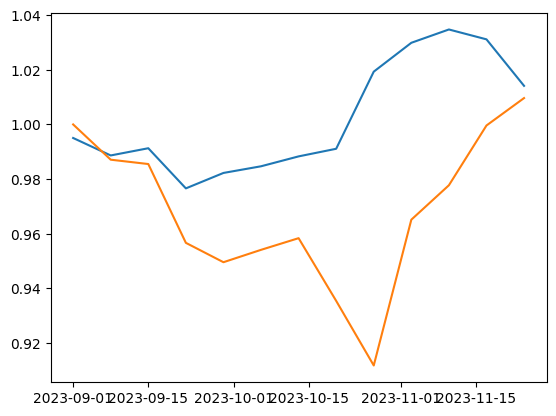

In [200]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [201]:
recommendations = trades.tail(positions)

In [202]:
recommendations

,date,abs,direction,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
143,2023-12-01 00:00:00+00:00,0.009932,-1.0,CHTR,Communication Services,401.87,NaN,2023,4,12,48,4
144,2023-12-01 00:00:00+00:00,0.001097,1.0,MCD,Consumer Discretionary,285.96,NaN,2023,4,12,48,4
145,2023-12-01 00:00:00+00:00,0.001619,1.0,PM,Consumer Staples,94.05,NaN,2023,4,12,48,4
146,2023-12-01 00:00:00+00:00,0.015349,1.0,XOM,Energy,102.99,NaN,2023,4,12,48,4
147,2023-12-01 00:00:00+00:00,0.039158,-1.0,AXP,Financials,173.76,NaN,2023,4,12,48,4
148,2023-12-01 00:00:00+00:00,0.006046,1.0,ABT,Health Care,104.88,NaN,2023,4,12,48,4
149,2023-12-01 00:00:00+00:00,0.002747,1.0,EMR,Industrials,90.12,NaN,2023,4,12,48,4
150,2023-12-01 00:00:00+00:00,0.014444,-1.0,ORCL,Information Technology,117.16,NaN,2023,4,12,48,4
151,2023-12-01 00:00:00+00:00,0.005716,-1.0,DOW,Materials,52.30,NaN,2023,4,12,48,4
152,2023-12-01 00:00:00+00:00,0.089851,-1.0,SPG,Real Estate,128.82,NaN,2023,4,12,48,4


In [182]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()